In [1]:
from ProjectFunctions import *

In [2]:
def staggered_magnetization(length, states):#, psi):
    #will calculate the staggered magnetization opertor
    #only works for degeneracy 2
    statesigns = []
    z = Q.sigmaz()
    I = Q.qeye(2)
    for spin in states[0]:
        if spin == '0':
            sign = 1
            statesigns.append(sign)
        elif spin == '1':
            sign = -1
            statesigns.append(sign)
            
            
            
    zterm = 0
    for i in range(length):
        # Pauli z matrix at each spin in the chain while the rest are identity
        term = Q.tensor([I] * i + [z] + [I] * (length - i - 1))
        #zterm += (staggersign * term)
        zterm += (statesigns[i] * term)
    stagmag = (1/length) * zterm
    #expectvalue = Q.expect((stagmag**2), psi)
    return stagmag#, expectvalue

In [3]:
def find_transitions(xaxis, stagmagvals, ratiodict, stdevdict, meandict):
    
    covarvals = []
    for key in ratiodict.keys():
        covarvals.append(ratiodict[key])
    
    stdevvals = []
    for key in stdevdict.keys():
        stdevvals.append(stdevdict[key])
    
    meanvals = []
    for key in meandict.keys():
        meanvals.append(meandict[key])
    
    
    # Calculate numerical derivatives (slope between adjacent points)
    dx = np.diff(xaxis)
    dstagmag = np.diff(stagmagvals)
    slopes1 = dstagmag / dx

    # Find the index of the maximum slope
    stagmag_slope_index = np.argmax(np.abs(slopes1))

    # Get the x and y values of the point with the maximum slope
    x_max_slope1 = xaxis[stagmag_slope_index + 1]  # +1 because slopes are between points
    stagmag_max_slope = stagmagvals[stagmag_slope_index + 1]

    print(f"Point of maximum slope for staggered magnetization: ({x_max_slope1}, {stagmag_max_slope})")
    
    # Calculate numerical derivatives (slope between adjacent points)
    xaxisnew = xaxis[-59:]
    
    dx = np.diff(xaxisnew)
    dmean = np.diff(meanvals[-59:])
    slopes2 = dmean / dx

    # Find the index of the maximum slope
    mean_slope_index = np.argmax(np.abs(slopes2))

    # Get the x and y values of the point with the maximum slope
    x_max_slope2 = xaxisnew[mean_slope_index + 1]  # +1 because slopes are between points
    mean_max_slope = meanvals[mean_slope_index + 1]

    print(f"Point of maximum slope for mean: ({x_max_slope2}, {mean_max_slope})")
    
    
    # Use scipy.signal.find_peaks to find the indices of the peaks
    peaks1, _ = scipy.signal.find_peaks(stdevvals)
    #print(peaks)

    # Print the x and y coordinates of the peaks
    peak_x1 = xaxis[peaks1[0]]
    peak_stdev = stdevvals[peaks1[0]]
    #print(peak_x1, peak_stdev)
    print(f"Peak for standard deviation: ({peak_x1}, {peak_stdev})")
    
    
    
    # Use scipy.signal.find_peaks to find the indices of the peaks
    peaks2, _ = scipy.signal.find_peaks(covarvals)
    #print(peaks)

    # Print the x and y coordinates of the peaks
    peak_x2 = xaxis[peaks2[0]]
    peak_covar = covarvals[peaks2[0]]
    #print(peak_x1, peak_covar)
    print(f"Peak for coefficient of variance: ({peak_x2}, {peak_covar})")
    
    return x_max_slope2, peak_x2, x_max_slope2, peak_x1

In [4]:
length = 8
hval = 0.001
jij = generate_jij(length, 14, 13)
Hint, Hintdiag = sg_interaction(length, jij)
Hfield = sg_field(length)
H = Hint + (hval * Hfield)
E, psi = H.groundstate()
Hintdiag, minenergy, degeneracy, groundpos, states = find_degeneracy(length, Hintdiag)
print(states)

['00110110', '11001001']


C:\Users\danny\anaconda3\Lib\site-packages\qutip\core\qobj.py:1626: UserWarning: Ground state may be degenerate.
  warnings.warn("Ground state may be degenerate.", UserWarning)


In [5]:
stagmag = staggered_magnetization(length, states)
print(stagmag)
#print(expectvalue)

Quantum object: dims=[[2, 2, 2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2, 2, 2]], shape=(256, 256), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.   -0.25  0.   ...  0.    0.    0.  ]
 [ 0.    0.    0.25 ...  0.    0.    0.  ]
 ...
 [ 0.    0.    0.   ... -0.25  0.    0.  ]
 [ 0.    0.    0.   ...  0.    0.25  0.  ]
 [ 0.    0.    0.   ...  0.    0.    0.  ]]


In [6]:
plotlist = []
for hval in np.arange(0.001, 6, 0.1):
    H = Hint + (hval * Hfield)
    E, psi = H.groundstate()
    expectvalue = Q.expect((stagmag**2), psi)
    plotlist.append(expectvalue)

In [7]:
%%time
hvals = np.arange(0.001, 6, 0.1)
alldist = {}
allminfo = {}
# Generate all possible pairs of positions
for h in hvals:
    distancelist = []
    minfolist = []
    H = Hint + (h * Hfield)
    E, psi = H.groundstate()
    for i in range(length):
        for j in range(i + 1, length):
            minfo, distance = mutual_info(length, psi, [i], [j])
            distancelist.append(distance)
            minfolist.append(minfo)
    alldist.update({h:distancelist})
    allminfo.update({h:minfolist})
#print(alldist)
ratiodict, maxh, maxratio, stdevdict, meandict = max_variance_ratio(alldist, hvals)

CPU times: total: 1min 6s
Wall time: 17.2 s


In [8]:
stagmag_max_slope, peak_covar, mean_max_slope, peak_stdev = find_transitions(np.arange(0.001, 6, 0.1), plotlist, ratiodict, stdevdict, meandict)

Point of maximum slope for staggered magnetization: (2.001, 0.5960449891732382)
Point of maximum slope for mean: (2.201, 1.9239977905803403)
Peak for standard deviation: (2.601, 0.9017634968245126)
Peak for coefficient of variance: (2.001, 0.41333471880827827)


In [11]:
print(stagmag_max_slope, peak_covar, mean_max_slope, peak_stdev)

2.201 2.001 2.201 2.601


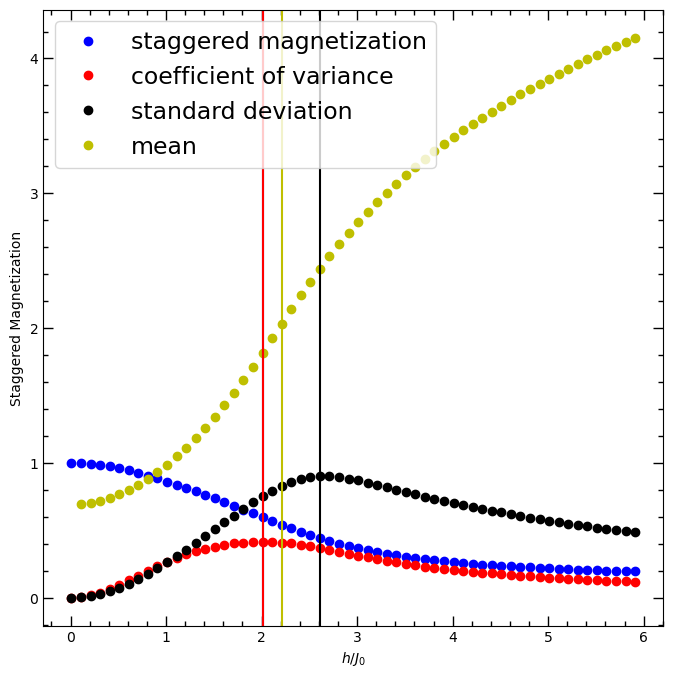

In [10]:
fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams.update({'font.size': 17})
# label the axes
ax.set_xlabel(r"$h/J_0$")
ax.set_ylabel(r"Staggered Magnetization")

# set the tick mark parameters
ax.minorticks_on()
ax.tick_params(which='both',direction="in",width=1)
ax.tick_params(which='major',length=7)
ax.tick_params(which='minor',length=3.5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

means = []
for val in meandict.values():
    means.append(val)

p1 = plt.plot(np.arange(0.01, 6, 0.1), plotlist, 'ob', label = 'staggered magnetization')
p2 = plt.plot(np.arange(0.01, 6, 0.1), ratiodict.values(), 'or', label = 'coefficient of variance')
p3 = plt.plot(np.arange(0.01, 6, 0.1), stdevdict.values(), 'ok', label = 'standard deviation')
p4 = plt.plot(np.arange(0.11, 6, 0.1), means[-59:], 'oy', label = 'mean')
#p1 = plt.plot(np.arange(0.01, 6, 0.1), newvalues1, 'ob', label = 'staggered magnetization')
#p2 = plt.plot(np.arange(0.01, 6, 0.1), newvalues2, 'or', label = 'coefficient of variance')
#p3 = plt.plot(np.arange(0.01, 6, 0.1), newvalues3, 'ok', label = 'standard deviation')
#p4 = plt.plot(np.arange(0.11, 6, 0.1), newvalues4[-59:], 'oy', label = 'mean')

transition1 = plt.axvline(x=2.01, color='b')
transtion2 = plt.axvline(x=2.01, color='r')
transition3 = plt.axvline(x=2.61, color='k')
transition4 = plt.axvline(x=2.21, color='y')
plt.legend()
#plt.savefig("Degen 4 Glass Model Ratio With Varied h New.pdf")
plt.show()